# Model Comparison

This notebook compares multiple regression models using the preprocessing
strategy selected in the previous experiments.

Model selection is performed using the training data only with the same
5-fold cross-validation procedure.

The final holdout set remains untouched during model selection.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [2]:
housing = fetch_openml(
    data_id=42165,
    as_frame=True
)

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

y_train_log = np.log1p(y_train)

In [3]:
class NeighborhoodLotFrontageImputer(
    BaseEstimator,
    TransformerMixin
):
    def fit(self, X, y=None):
        self.neighborhood_medians_ = (
            X.groupby("Neighborhood")["LotFrontage"]
            .median()
        )

        self.global_median_ = X["LotFrontage"].median()

        return self

    def transform(self, X):
        X = X.copy()

        neighborhood_fill_values = (
            X["Neighborhood"]
            .map(self.neighborhood_medians_)
            .fillna(self.global_median_)
        )

        X["LotFrontage"] = X["LotFrontage"].fillna(
            neighborhood_fill_values
        )

        return X[["LotFrontage"]]

In [4]:
numeric_features = X_train.select_dtypes(
    include="number"
).columns

categorical_features = X_train.select_dtypes(
    exclude="number"
).columns

numeric_features_without_lot_frontage = (
    numeric_features.drop("LotFrontage")
)

In [5]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

lot_frontage_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            NeighborhoodLotFrontageImputer()
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features_without_lot_frontage
        ),
        (
            "lot_frontage",
            lot_frontage_pipeline,
            ["LotFrontage", "Neighborhood"]
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [7]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=30.0))
    ]
)

In [9]:
ridge_scores = -cross_val_score(
    ridge_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

ridge_scores.mean(), ridge_scores.std()

(np.float64(0.14112493981702662), np.float64(0.030378955110455932))

## Lasso Regression

Lasso regression applies L1 regularization, penalizing the absolute magnitude
of model coefficients.

Unlike Ridge regression, Lasso can shrink some coefficients exactly to zero,
which allows it to perform implicit feature selection.

Because the scale of the Lasso regularization parameter is different from Ridge,
a separate range of smaller alpha values is evaluated using the same
cross-validation procedure.

In [10]:
lasso_alphas = [
    0.0001,
    0.0003,
    0.001,
    0.003,
    0.01,
    0.03,
    0.1
]

In [11]:
lasso_results = []

for alpha in lasso_alphas:
    lasso_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                Lasso(
                    alpha=alpha,
                    max_iter=20000
                )
            )
        ]
    )

    scores = -cross_val_score(
        lasso_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    lasso_results.append({
        "alpha": alpha,
        "mean_cv_rmse": scores.mean(),
        "std_cv_rmse": scores.std()
    })

In [12]:
lasso_results_df = pd.DataFrame(
    lasso_results
)

lasso_results_df.sort_values("mean_cv_rmse")

,alpha,mean_cv_rmse,std_cv_rmse
2,0.0010,0.140050,0.033570
1,0.0003,0.144341,0.032780
3,0.0030,0.148013,0.033662
0,0.0001,0.151704,0.030221
4,0.0100,0.157988,0.033904
5,0.0300,0.173354,0.027746
6,0.1000,0.221974,0.014043


### Lasso Result

Lasso performance improves as regularization increases up to approximately
`alpha=0.001`.

At this value, the model achieves a mean cross-validation RMSE of approximately
0.1400, slightly outperforming the selected Ridge model.

Stronger regularization rapidly worsens performance, indicating that excessive
coefficient shrinkage causes underfitting.

Although Lasso achieves a slightly lower mean RMSE than Ridge, its
cross-validation variability is somewhat higher. Therefore, the difference
should not yet be interpreted as strong evidence that Lasso is superior.

In [13]:
lasso_selected_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            Lasso(
                alpha=0.001,
                max_iter=20000
            )
        )
    ]
)

lasso_selected_model.fit(
    X_train,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('lot_frontage', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

In [14]:
lasso_coefs = (
    lasso_selected_model
    .named_steps["model"]
    .coef_
)

In [15]:
n_total = len(lasso_coefs)

n_zero = np.sum(
    lasso_coefs == 0
)

n_nonzero = np.sum(
    lasso_coefs != 0
)

n_total, n_zero, n_nonzero

(303, np.int64(217), np.int64(86))

### Lasso Sparsity

After fitting the selected Lasso model on the full training set, 217 of the
303 transformed feature coefficients are exactly zero, leaving 86 non-zero
coefficients.

This confirms that Lasso performs substantial implicit feature selection in
this dataset.

However, a zero coefficient should not be interpreted as evidence that the
corresponding feature is inherently unimportant. With correlated predictors,
Lasso may select one feature while shrinking a similar predictor to zero, and
the selected set may change across different samples.

## ElasticNet Regression

ElasticNet combines L1 and L2 regularization.

The `alpha` parameter controls the overall strength of regularization, while
`l1_ratio` controls the balance between L1 and L2 penalties.

- Higher `l1_ratio` values make ElasticNet behave more like Lasso.
- Lower `l1_ratio` values make it behave more like Ridge.

A limited hyperparameter search is used to compare several reasonable
combinations without excessively tuning to the same cross-validation folds.

In [16]:
elasticnet_alphas = [
    0.0003,
    0.001,
    0.003,
    0.01
]

elasticnet_l1_ratios = [
    0.2,
    0.5,
    0.8
]

In [17]:
elasticnet_results = []

for alpha in elasticnet_alphas:
    for l1_ratio in elasticnet_l1_ratios:

        elasticnet_model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                (
                    "model",
                    ElasticNet(
                        alpha=alpha,
                        l1_ratio=l1_ratio,
                        max_iter=20000
                    )
                )
            ]
        )

        scores = -cross_val_score(
            elasticnet_model,
            X_train,
            y_train_log,
            cv=cv,
            scoring="neg_root_mean_squared_error"
        )

        elasticnet_results.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "mean_cv_rmse": scores.mean(),
            "std_cv_rmse": scores.std()
        })

In [18]:
elasticnet_results_df = pd.DataFrame(
    elasticnet_results
)

elasticnet_results_df.sort_values(
    "mean_cv_rmse"
)

,alpha,l1_ratio,mean_cv_rmse,std_cv_rmse
5,0.0010,0.8,0.139793,0.033000
4,0.0010,0.5,0.139903,0.032094
6,0.0030,0.2,0.140163,0.030785
7,0.0030,0.5,0.142187,0.032054
3,0.0010,0.2,0.143646,0.030110
9,0.0100,0.2,0.144462,0.032933
2,0.0003,0.8,0.144978,0.032132
8,0.0030,0.8,0.145662,0.033389
1,0.0003,0.5,0.146905,0.030790
0,0.0003,0.2,0.150650,0.028011


### ElasticNet Result

ElasticNet achieves its lowest mean cross-validation RMSE with
`alpha=0.001` and `l1_ratio=0.8`, reaching approximately 0.1398.

This slightly improves upon both the selected Lasso and Ridge models.

However, the improvement over Lasso is very small, so the result should not
be interpreted as strong evidence that ElasticNet is substantially superior.

A second configuration, `alpha=0.003` and `l1_ratio=0.2`, achieves a very
similar mean RMSE with lower fold-to-fold variability, illustrating the
trade-off between average predictive performance and cross-validation
stability.

Overall, the strongest ElasticNet configurations perform similarly to Lasso
while combining L1 and L2 regularization.

In [19]:
selected_elasticnet_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ElasticNet(
                alpha=0.001,
                l1_ratio=0.8,
                max_iter=20000
            )
        )
    ]
)

selected_elasticnet_model.fit(
    X_train,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('lot_frontage', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

In [20]:
elasticnet_coefs = (
    selected_elasticnet_model
    .named_steps["model"]
    .coef_
)

In [21]:
n_total = len(elasticnet_coefs)
n_zero = np.sum(elasticnet_coefs == 0)
n_nonzero = np.sum(elasticnet_coefs != 0)

n_total, n_zero, n_nonzero

(303, np.int64(207), np.int64(96))

### ElasticNet Sparsity

The selected ElasticNet model retains 96 non-zero coefficients out of 303
transformed features, compared with 86 non-zero coefficients for the selected
Lasso model.

ElasticNet therefore produces a slightly less sparse solution than Lasso.

This is consistent with the presence of the L2 component in ElasticNet, which
can help retain groups of correlated predictors instead of forcing one or more
of them completely to zero.

However, sparsity alone is not used to determine the preferred model; predictive
performance and cross-validation stability remain the primary criteria.

In [22]:
linear_model_results = pd.DataFrame({
    "model": [
        "Ridge",
        "Lasso",
        "ElasticNet"
    ],
    "mean_cv_rmse": [
        ridge_scores.mean(),
        lasso_results_df.loc[
            lasso_results_df["alpha"] == 0.001,
            "mean_cv_rmse"
        ].iloc[0],
        elasticnet_results_df.loc[
            (elasticnet_results_df["alpha"] == 0.001) &
            (elasticnet_results_df["l1_ratio"] == 0.8),
            "mean_cv_rmse"
        ].iloc[0]
    ],
    "std_cv_rmse": [
        ridge_scores.std(),
        lasso_results_df.loc[
            lasso_results_df["alpha"] == 0.001,
            "std_cv_rmse"
        ].iloc[0],
        elasticnet_results_df.loc[
            (elasticnet_results_df["alpha"] == 0.001) &
            (elasticnet_results_df["l1_ratio"] == 0.8),
            "std_cv_rmse"
        ].iloc[0]
    ]
})

linear_model_results.sort_values("mean_cv_rmse")

,model,mean_cv_rmse,std_cv_rmse
2,ElasticNet,0.139793,0.033000
1,Lasso,0.140050,0.033570
0,Ridge,0.141125,0.030379


## Random Forest Regression

Random Forest is evaluated as the first non-linear model.

Unlike regularized linear models, tree-based models do not require numerical
feature standardization because their splits depend primarily on feature ordering
and threshold values rather than coefficient magnitudes.

The same missing-value handling and categorical encoding strategy is retained,
but numerical scaling is removed.

The log-transformed target and the same 5-fold cross-validation procedure are
used to maintain a consistent evaluation framework.

In [23]:
tree_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

tree_lot_frontage_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            NeighborhoodLotFrontageImputer()
        )
    ]
)

In [24]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            numeric_features_without_lot_frontage
        ),
        (
            "lot_frontage",
            tree_lot_frontage_pipeline,
            ["LotFrontage", "Neighborhood"]
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [25]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

In [26]:
random_forest_scores = -cross_val_score(
    random_forest_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

random_forest_scores

array([0.14897573, 0.15184672, 0.17494222, 0.13654481, 0.12899994])

In [27]:
random_forest_scores.mean(), random_forest_scores.std()

(np.float64(0.1482618835567221), np.float64(0.01570677085993546))

### Random Forest Baseline Result

The baseline Random Forest model achieves a mean cross-validation RMSE of
approximately 0.1483.

This is noticeably worse than the regularized linear models, particularly
ElasticNet and Lasso.

However, Random Forest shows substantially lower fold-to-fold variability,
with a standard deviation of approximately 0.0157.

This suggests that the model is relatively stable across validation folds,
but its average predictive accuracy is currently weaker.

Further limited tuning is therefore justified before deciding whether Random
Forest should remain a competitive candidate.


### Random Forest Hyperparameter Search

A limited hyperparameter search is performed to evaluate whether controlling
tree complexity and feature randomness can improve Random Forest performance.

Two parameters are examined:

- `max_features`: controls the proportion of features considered at each split.
- `min_samples_leaf`: controls the minimum number of observations required in
  each leaf.

The search is intentionally kept small to avoid excessive tuning on the same
cross-validation folds.

In [28]:
rf_max_features = [
    0.5,
    0.75,
    1.0
]

rf_min_samples_leaf = [
    1,
    2,
    4
]

In [29]:
rf_results = []

for max_features in rf_max_features:
    for min_samples_leaf in rf_min_samples_leaf:

        rf_model = Pipeline(
            steps=[
                ("preprocessor", tree_preprocessor),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=500,
                        max_features=max_features,
                        min_samples_leaf=min_samples_leaf,
                        random_state=42,
                        n_jobs=1
                    )
                )
            ]
        )

        scores = -cross_val_score(
            rf_model,
            X_train,
            y_train_log,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )

        rf_results.append({
            "max_features": max_features,
            "min_samples_leaf": min_samples_leaf,
            "mean_cv_rmse": scores.mean(),
            "std_cv_rmse": scores.std()
        })

In [30]:
rf_results_df = pd.DataFrame(
    rf_results
)

rf_results_df.sort_values(
    "mean_cv_rmse"
)

,max_features,min_samples_leaf,mean_cv_rmse,std_cv_rmse
0,0.50,1,0.141866,0.014604
1,0.50,2,0.142550,0.015012
3,0.75,1,0.144536,0.014509
4,0.75,2,0.144631,0.015186
2,0.50,4,0.145361,0.015072
5,0.75,4,0.147443,0.015603
6,1.00,1,0.148262,0.015707
7,1.00,2,0.148584,0.016798
8,1.00,4,0.151172,0.017080


### Random Forest Tuning Result

The limited Random Forest search substantially improves performance over the
baseline model.

The best tested configuration uses `max_features=0.5` and
`min_samples_leaf=1`, achieving a mean cross-validation RMSE of approximately
0.1419.

Reducing `max_features` consistently improves performance, suggesting that
increasing randomness among individual trees benefits the ensemble.

Increasing `min_samples_leaf` does not improve performance in the tested range;
the smallest value of 1 performs best across all evaluated `max_features`
settings.

Although the tuned Random Forest approaches Ridge performance, it still
slightly underperforms the strongest regularized linear models.

In [31]:
rf_max_features_extended = [
    0.25,
    0.35,
    0.5,
    0.65
]

In [32]:
rf_extended_results = []

for max_features in rf_max_features_extended:

    rf_model = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=500,
                    max_features=max_features,
                    min_samples_leaf=1,
                    random_state=42,
                    n_jobs=1
                )
            )
        ]
    )

    scores = -cross_val_score(
        rf_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rf_extended_results.append({
        "max_features": max_features,
        "mean_cv_rmse": scores.mean(),
        "std_cv_rmse": scores.std()
    })

In [33]:
rf_extended_results_df = pd.DataFrame(
    rf_extended_results
)

rf_extended_results_df.sort_values(
    "mean_cv_rmse"
)

,max_features,mean_cv_rmse,std_cv_rmse
0,0.25,0.140318,0.014645
1,0.35,0.140818,0.015014
2,0.50,0.141866,0.014604
3,0.65,0.143240,0.014126


### Extended Random Forest Search Result

Reducing `max_features` further improves Random Forest performance.

The best tested configuration uses `max_features=0.25` and
`min_samples_leaf=1`, achieving a mean cross-validation RMSE of approximately
0.1403.

This represents a substantial improvement over the original Random Forest
baseline and brings performance close to the strongest regularized linear
models.

Although the best value occurs at the lower boundary of the tested range,
additional fine-grained tuning is not pursued to limit repeated optimization
against the same cross-validation folds.

The configuration with `max_features=0.25` is retained as the current Random
Forest candidate.

In [34]:
selected_random_forest_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_features=0.25,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

## Gradient Boosting Regression

Gradient Boosting builds trees sequentially rather than independently.

Each new tree attempts to reduce the prediction errors remaining from the
previous ensemble, allowing the model to progressively improve difficult
predictions.

Unlike Random Forest, which primarily reduces variance through averaging,
Gradient Boosting reduces error through sequential correction.

A baseline model is evaluated before performing any hyperparameter tuning.

In [35]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

In [36]:
gradient_boosting_scores = -cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gradient_boosting_scores

array([0.13257271, 0.14023125, 0.15681789, 0.11708627, 0.11017206])

In [37]:
gradient_boosting_scores.mean(), gradient_boosting_scores.std()

(np.float64(0.1313760337402436), np.float64(0.016618910171137286))

### Gradient Boosting Baseline Result

The default Gradient Boosting model achieves a mean cross-validation RMSE of
approximately 0.1314.

This substantially outperforms the regularized linear models and the tuned
Random Forest model evaluated so far.

The model also shows relatively low fold-to-fold variability in this 5-fold
evaluation.

Because Gradient Boosting performs strongly even before tuning, a limited
hyperparameter search is justified.

In [38]:
gb_learning_rates = [
    0.03,
    0.05,
    0.1
]

gb_n_estimators = [
    100,
    300,
    500
]

In [39]:
gb_results = []

for learning_rate in gb_learning_rates:
    for n_estimators in gb_n_estimators:

        gb_model = Pipeline(
            steps=[
                ("preprocessor", tree_preprocessor),
                (
                    "model",
                    GradientBoostingRegressor(
                        learning_rate=learning_rate,
                        n_estimators=n_estimators,
                        random_state=42
                    )
                )
            ]
        )

        scores = -cross_val_score(
            gb_model,
            X_train,
            y_train_log,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )

        gb_results.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            "mean_cv_rmse": scores.mean(),
            "std_cv_rmse": scores.std()
        })

In [40]:
gb_results_df = pd.DataFrame(
    gb_results
)

gb_results_df.sort_values(
    "mean_cv_rmse"
)

,learning_rate,n_estimators,mean_cv_rmse,std_cv_rmse
8,0.10,500,0.128161,0.015755
7,0.10,300,0.128181,0.016193
5,0.05,500,0.128255,0.015501
4,0.05,300,0.129056,0.016177
2,0.03,500,0.129151,0.016702
6,0.10,100,0.131376,0.016619
1,0.03,300,0.131432,0.017038
3,0.05,100,0.139023,0.015383
0,0.03,100,0.152556,0.014129


### Gradient Boosting Learning-Rate and Estimator Search

Increasing the number of boosting stages substantially improves performance,
particularly when smaller learning rates are used.

The best tested mean cross-validation RMSE is approximately 0.1282 with
`learning_rate=0.1` and `n_estimators=500`.

However, `learning_rate=0.1` with `n_estimators=300` achieves nearly identical
performance with fewer trees, while `learning_rate=0.05` and
`n_estimators=500` also performs similarly.

These results indicate that several configurations lie within a very narrow
performance range, so the smallest numerical difference should not be
over-interpreted.

### Gradient Boosting Tree Complexity

After identifying a suitable learning-rate and estimator range, tree complexity
is evaluated separately.

The number of estimators is fixed at 300 with `learning_rate=0.1`, since this
configuration achieves nearly the same cross-validation performance as the
500-estimator model with lower computational cost.

The `max_depth` parameter is varied to examine whether simpler or more complex
base trees improve generalization.

In [41]:
gb_max_depths = [
    1,
    2,
    3,
    4
]

In [42]:
gb_depth_results = []

for max_depth in gb_max_depths:

    gb_model = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                GradientBoostingRegressor(
                    learning_rate=0.1,
                    n_estimators=300,
                    max_depth=max_depth,
                    random_state=42
                )
            )
        ]
    )

    scores = -cross_val_score(
        gb_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    gb_depth_results.append({
        "max_depth": max_depth,
        "mean_cv_rmse": scores.mean(),
        "std_cv_rmse": scores.std()
    })

In [43]:
gb_depth_results_df = pd.DataFrame(
    gb_depth_results
)

gb_depth_results_df.sort_values(
    "mean_cv_rmse"
)

,max_depth,mean_cv_rmse,std_cv_rmse
2,3,0.128181,0.016193
1,2,0.128561,0.017351
3,4,0.129946,0.015403
0,1,0.131959,0.020600


### Gradient Boosting Tree-Depth Result

The best tested tree depth is `max_depth=3`, with a mean cross-validation RMSE
of approximately 0.1282.

Shallower trees, particularly `max_depth=1`, perform worse, suggesting that
very simple base learners underfit the data.

Increasing depth beyond 3 does not provide a meaningful improvement, indicating
that additional tree complexity is not justified in the tested range.

Therefore, `max_depth=3` is retained for the current Gradient Boosting candidate.

In [44]:
selected_gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                learning_rate=0.1,
                n_estimators=300,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

## Model Comparison Summary

The selected configurations from each model family are compared using the same
5-fold cross-validation procedure.

All results are based exclusively on the training portion of the dataset.
The final holdout set remains untouched.

Cross-validation results are used for model selection rather than as an
unbiased estimate of final generalization performance, since the same folds
have been consulted repeatedly during model development.

In [45]:
model_comparison = pd.DataFrame({
    "model": [
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Random Forest",
        "Gradient Boosting"
    ],
    "mean_cv_rmse": [
        ridge_scores.mean(),

        lasso_results_df.loc[
            lasso_results_df["alpha"] == 0.001,
            "mean_cv_rmse"
        ].iloc[0],

        elasticnet_results_df.loc[
            (elasticnet_results_df["alpha"] == 0.001) &
            (elasticnet_results_df["l1_ratio"] == 0.8),
            "mean_cv_rmse"
        ].iloc[0],

        rf_extended_results_df.loc[
            rf_extended_results_df["max_features"] == 0.25,
            "mean_cv_rmse"
        ].iloc[0],

        gb_depth_results_df.loc[
            gb_depth_results_df["max_depth"] == 3,
            "mean_cv_rmse"
        ].iloc[0]
    ],
    "std_cv_rmse": [
        ridge_scores.std(),

        lasso_results_df.loc[
            lasso_results_df["alpha"] == 0.001,
            "std_cv_rmse"
        ].iloc[0],

        elasticnet_results_df.loc[
            (elasticnet_results_df["alpha"] == 0.001) &
            (elasticnet_results_df["l1_ratio"] == 0.8),
            "std_cv_rmse"
        ].iloc[0],

        rf_extended_results_df.loc[
            rf_extended_results_df["max_features"] == 0.25,
            "std_cv_rmse"
        ].iloc[0],

        gb_depth_results_df.loc[
            gb_depth_results_df["max_depth"] == 3,
            "std_cv_rmse"
        ].iloc[0]
    ]
})

model_comparison.sort_values("mean_cv_rmse")

,model,mean_cv_rmse,std_cv_rmse
4,Gradient Boosting,0.128181,0.016193
2,ElasticNet,0.139793,0.033000
1,Lasso,0.140050,0.033570
3,Random Forest,0.140318,0.014645
0,Ridge,0.141125,0.030379


## Semantic Feature-Type Experiment

Some predictors are stored numerically but do not represent continuous
quantities.

In particular:

- `MSSubClass` represents building-class categories.
- `MoSold` represents calendar months.

Treating these variables as ordinary numerical features may impose inappropriate
numeric structure on the model.

As a controlled experiment, these two variables are encoded categorically while
all other preprocessing, model settings, and cross-validation folds remain
unchanged.

In [46]:
semantic_categorical_features = [
    "MSSubClass",
    "MoSold"
]

semantic_numeric_features = (
    numeric_features_without_lot_frontage
    .drop(semantic_categorical_features)
)

In [47]:
semantic_categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [48]:
semantic_tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            semantic_numeric_features
        ),
        (
            "lot_frontage",
            tree_lot_frontage_pipeline,
            ["LotFrontage", "Neighborhood"]
        ),
        (
            "semantic_categorical",
            semantic_categorical_pipeline,
            semantic_categorical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [49]:
semantic_gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            semantic_tree_preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                learning_rate=0.1,
                n_estimators=300,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [50]:
semantic_gb_scores = -cross_val_score(
    semantic_gradient_boosting_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

semantic_gb_scores

array([0.1276064 , 0.14273958, 0.15252303, 0.1149135 , 0.10914108])

### Semantic Feature-Type Result

Treating `MSSubClass` and `MoSold` as categorical variables did not improve
Gradient Boosting performance.

The semantic representation achieved a mean cross-validation RMSE of
approximately 0.1294, compared with approximately 0.1282 for the original
dtype-based preprocessing.

Although categorical treatment may be semantically reasonable for these
features, it does not provide a predictive benefit in the current modeling
setup.

The original preprocessing representation is therefore retained.

## Final Holdout Evaluation

Model selection and preprocessing decisions have been completed using the
training data and cross-validation only.

The selected Gradient Boosting pipeline is now fitted on the full training set
and evaluated once on the untouched holdout set.

The holdout result is used as the final estimate of model generalization
performance and will not be used for further model tuning.

In [51]:
y_test_log = np.log1p(y_test)

In [52]:
final_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                learning_rate=0.1,
                n_estimators=300,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [53]:
final_model.fit(
    X_train,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('lot_frontage', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

In [54]:
y_test_log_pred = final_model.predict(
    X_test
)

In [55]:
final_test_rmse = root_mean_squared_error(
    y_test_log,
    y_test_log_pred
)

final_test_rmse

0.14099309366610185

### Final Holdout Result

The selected Gradient Boosting model achieves a final holdout RMSE of
approximately 0.1410 on the log-transformed target.

This is higher than the mean cross-validation RMSE of approximately 0.1282,
but remains broadly consistent with the variability observed across the
cross-validation folds.

The holdout set was evaluated once for final predictive performance.
Subsequent use of the holdout data was limited to post-hoc model interpretation
and error analysis; no further model tuning was performed.

In [56]:
y_test_pred = np.expm1(
    y_test_log_pred
)

In [57]:
error_analysis = pd.DataFrame(
    {
        "actual_price": y_test,
        "predicted_price": y_test_pred
    },
    index=y_test.index
)

error_analysis["error"] = (
    error_analysis["predicted_price"]
    - error_analysis["actual_price"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"].abs()
)

error_analysis["percentage_error"] = (
    error_analysis["absolute_error"]
    / error_analysis["actual_price"]
    * 100
)

In [58]:
error_analysis.describe()

,actual_price,predicted_price,error,absolute_error,percentage_error
count,292.000000,292.000000,292.000000,292.000000,292.000000
mean,178839.811644,175944.695129,-2895.116515,16719.293163,9.507255
std,87730.751259,75970.710248,31257.893965,26551.291370,13.288462
min,35311.000000,50103.204800,-282336.138140,0.904598,0.000880
25%,127000.000000,124638.966912,-9899.434512,4395.314543,2.686683
50%,154150.000000,152836.049130,-495.437617,9859.680381,5.962488
75%,209175.000000,208166.966289,8695.664418,19503.985676,11.482603
max,755000.000000,551310.441516,118794.814315,282336.138140,156.043572


In [59]:
error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,actual_price,predicted_price,error,absolute_error,percentage_error
898,611657,329320.861860,-282336.138140,282336.138140,46.159226
691,755000,551310.441516,-203689.558484,203689.558484,26.978749
774,395000,240622.906291,-154377.093709,154377.093709,39.082809
1046,556581,432233.735593,-124347.264407,124347.264407,22.341270
581,253293,372087.814315,118794.814315,118794.814315,46.900157
350,318061,239430.820587,-78630.179413,78630.179413,24.721729
218,311500,235547.578325,-75952.421675,75952.421675,24.382800
261,276000,346213.094617,70213.094617,70213.094617,25.439527
451,280000,211693.284534,-68306.715466,68306.715466,24.395256
588,143000,209035.572498,66035.572498,66035.572498,46.178722


In [60]:
error_details = X_test[
    [
        "OverallQual",
        "GrLivArea",
        "Neighborhood",
        "YearBuilt",
        "GarageCars"
    ]
].join(error_analysis)

In [61]:
error_details.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,OverallQual,GrLivArea,Neighborhood,YearBuilt,GarageCars,actual_price,predicted_price,error,absolute_error,percentage_error
898,9,2364,NridgHt,2009,3,611657,329320.861860,-282336.138140,282336.138140,46.159226
691,10,4316,NoRidge,1994,3,755000,551310.441516,-203689.558484,203689.558484,26.978749
774,8,1973,NridgHt,2006,3,395000,240622.906291,-154377.093709,154377.093709,39.082809
1046,9,2868,StoneBr,2005,3,556581,432233.735593,-124347.264407,124347.264407,22.341270
581,8,2042,NridgHt,2008,3,253293,372087.814315,118794.814315,118794.814315,46.900157
350,9,1869,NridgHt,2007,2,318061,239430.820587,-78630.179413,78630.179413,24.721729
218,7,1954,Crawfor,1939,2,311500,235547.578325,-75952.421675,75952.421675,24.382800
261,8,2574,CollgCr,2007,3,276000,346213.094617,70213.094617,70213.094617,25.439527
451,7,1533,ClearCr,1975,2,280000,211693.284534,-68306.715466,68306.715466,24.395256
588,5,1473,ClearCr,1968,1,143000,209035.572498,66035.572498,66035.572498,46.178722


In [62]:
error_analysis["log_residual"] = (
    y_test_log_pred - y_test_log
)

In [63]:
error_analysis["absolute_log_residual"] = (
    error_analysis["log_residual"].abs()
)

In [64]:
error_analysis.sort_values(
    "absolute_log_residual",
    ascending=False
).head(10)

,actual_price,predicted_price,error,absolute_error,percentage_error,log_residual,absolute_log_residual
30,40000,102417.428925,62417.428925,62417.428925,156.043572,0.940162,0.940162
898,611657,329320.861860,-282336.138140,282336.138140,46.159226,-0.619138,0.619138
916,35311,59208.817629,23897.817629,23897.817629,67.678111,0.516865,0.516865
812,55993,93614.197824,37621.197824,37621.197824,67.189109,0.513948,0.513948
774,395000,240622.906291,-154377.093709,154377.093709,39.082809,-0.495653,0.495653
1432,64500,104047.453867,39547.453867,39547.453867,61.313882,0.478176,0.478176
581,253293,372087.814315,118794.814315,118794.814315,46.900157,0.384582,0.384582
588,143000,209035.572498,66035.572498,66035.572498,46.178722,0.379658,0.379658
589,79500,112348.227827,32848.227827,32848.227827,41.318526,0.345843,0.345843
1131,93500,129532.446914,36032.446914,36032.446914,38.537376,0.325967,0.325967


In [65]:
error_analysis["price_group"] = pd.qcut(
    error_analysis["actual_price"],
    q=4,
    labels=[
        "Low",
        "Mid-Low",
        "Mid-High",
        "High"
    ]
)

price_group_errors = (
    error_analysis
    .groupby(
        "price_group",
        observed=True
    )
    .agg(
        count=("actual_price", "size"),
        mean_actual_price=("actual_price", "mean"),
        mean_error=("error", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        mean_percentage_error=("percentage_error", "mean"),
        mean_absolute_log_residual=(
            "absolute_log_residual",
            "mean"
        )
    )
)

price_group_errors

,count,mean_actual_price,mean_error,mean_absolute_error,mean_percentage_error,mean_absolute_log_residual
price_group,,,,,,
Low,75,101607.413333,5870.317240,11099.911528,13.796522,0.118625
Mid-Low,71,139672.633803,-897.801720,10012.124947,7.148457,0.072002
Mid-High,73,179376.356164,47.117675,11800.031830,6.612775,0.066273
High,73,295745.726027,-16785.527172,33935.301976,10.289128,0.109591


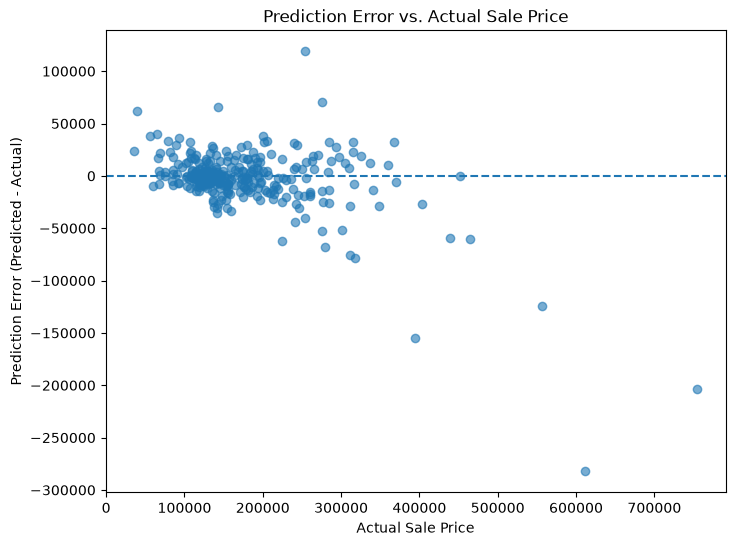

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(
    error_analysis["actual_price"],
    error_analysis["error"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Prediction Error (Predicted - Actual)")
plt.title("Prediction Error vs. Actual Sale Price")

plt.show()

### Price-Segment Error Analysis

Prediction errors vary systematically across price segments.

The lowest-price quartile is overpredicted by approximately $5,900 on average,
while the highest-price quartile is underpredicted by approximately $16,800.

In contrast, the two middle price groups show little systematic bias.

Relative errors also increase at both extremes of the price distribution.
Mean percentage error is approximately 13.8% in the lowest-price group and
10.3% in the highest-price group, compared with roughly 6–7% in the middle
groups.

The residual plot and grouped error statistics therefore suggest a tendency
for predictions at the extremes to regress toward the center of the observed
price distribution.

This holdout analysis is used only to characterize model behavior and is not
used for additional model tuning.

## Feature Importance

Feature importance is examined for the final Gradient Boosting model to better
understand which transformed predictors contribute most strongly to its
predictions.

Because categorical variables are one-hot encoded, the model operates on a
larger transformed feature space rather than directly on the original columns.

Feature names are therefore reconstructed from the fitted preprocessing
pipeline before being matched with the model's feature importance values.

In [67]:
feature_importances = (
    final_model
    .named_steps["model"]
    .feature_importances_
)

len(feature_importances)

303

In [68]:
numeric_feature_names = (
    numeric_features_without_lot_frontage
    .tolist()
)

In [69]:
lot_frontage_feature_names = [
    "LotFrontage"
]

In [70]:
fitted_encoder = (
    final_model
    .named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["encoder"]
)

In [71]:
categorical_feature_names = (
    fitted_encoder
    .get_feature_names_out(
        categorical_features
    )
    .tolist()
)

In [72]:
feature_names = (
    numeric_feature_names
    + lot_frontage_feature_names
    + categorical_feature_names
)

In [73]:
len(feature_names), len(feature_importances)

(303, 303)

In [74]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
})

In [75]:
feature_importance_df.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
3,OverallQual,0.423284
15,GrLivArea,0.187840
5,YearBuilt,0.048751
11,TotalBsmtSF,0.045061
25,GarageCars,0.043453
8,BsmtFinSF1,0.028218
6,YearRemodAdd,0.026623
26,GarageArea,0.019949
2,LotArea,0.018234
12,1stFlrSF,0.013039


### Gradient Boosting Feature Importance

The fitted Gradient Boosting model places the greatest importance on
`OverallQual` and `GrLivArea`.

`OverallQual` accounts for the largest share of impurity-based importance,
followed by above-ground living area, construction year, basement area, and
garage capacity.

These findings are broadly consistent with the exploratory analysis, where
overall quality and living area also showed strong relationships with sale
price.

However, impurity-based feature importance should not be interpreted causally.
It reflects how frequently and effectively the fitted trees use each feature
to reduce prediction error.

Importance may also be distributed across correlated predictors, so a lower
importance value does not necessarily imply that a feature contains no useful
information.

### Aggregated Original-Feature Importance

One-hot encoding distributes the importance of a categorical predictor across
multiple dummy variables.

To make interpretation more meaningful, importance values associated with the
same original categorical feature are aggregated.

This allows original predictors such as `Neighborhood` or `KitchenQual` to be
compared more directly with numerical predictors such as `OverallQual` and
`GrLivArea`.

In [76]:
categorical_original_names = []

for feature, categories in zip(
    categorical_features,
    fitted_encoder.categories_
):
    categorical_original_names.extend(
        [feature] * len(categories)
    )

In [77]:
original_feature_names = (
    numeric_feature_names
    + lot_frontage_feature_names
    + categorical_original_names
)

In [78]:
len(original_feature_names), len(feature_importances)

(303, 303)

In [79]:
grouped_feature_importance_df = pd.DataFrame({
    "transformed_feature": feature_names,
    "original_feature": original_feature_names,
    "importance": feature_importances
})

In [80]:
original_feature_importance = (
    grouped_feature_importance_df
    .groupby(
        "original_feature",
        as_index=False
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False
    )
)

original_feature_importance.head(20)

,original_feature,importance
63,OverallQual,0.423284
38,GrLivArea,0.187840
77,YearBuilt,0.048751
74,TotalBsmtSF,0.045061
32,GarageCars,0.043453
8,BsmtFinSF1,0.028218
78,YearRemodAdd,0.026623
31,GarageArea,0.019949
48,LotArea,0.018234
16,CentralAir,0.015327


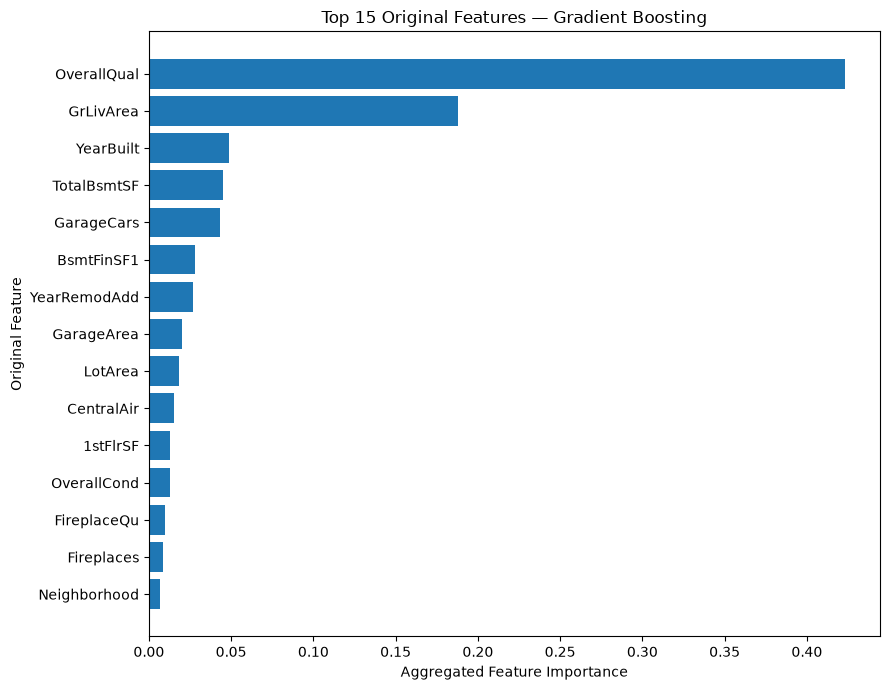

In [81]:
top_original_features = (
    original_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_original_features["original_feature"],
    top_original_features["importance"]
)

plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Original Feature")
plt.title("Top 15 Original Features — Gradient Boosting")

plt.tight_layout()
plt.show()

### Permutation Importance

Permutation importance evaluates feature relevance by measuring how much model
performance deteriorates when the values of an individual predictor are randomly
shuffled.

Unlike impurity-based tree importance, permutation importance is evaluated on
the original input features and directly measures the effect of disrupting each
feature on predictive performance.

The analysis is performed on the already-evaluated holdout set strictly for
model interpretation. No further model tuning is performed based on these
results.

In [82]:
permutation_result = permutation_importance(
    final_model,
    X_test,
    y_test_log,
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [83]:
permutation_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

In [84]:
permutation_importance_df.sort_values(
    "importance_mean",
    ascending=False
).head(20)

,feature,importance_mean,importance_std
46,GrLivArea,0.086420,0.004906
17,OverallQual,0.081898,0.006025
19,YearBuilt,0.015817,0.001826
38,TotalBsmtSF,0.015158,0.002746
20,YearRemodAdd,0.010767,0.002808
18,OverallCond,0.009858,0.001633
61,GarageCars,0.008399,0.001631
4,LotArea,0.006383,0.001470
41,CentralAir,0.005336,0.000730
12,Neighborhood,0.005034,0.001345


### Permutation Importance Result

Permutation importance confirms that `GrLivArea` and `OverallQual` are the
most influential predictors for the final Gradient Boosting model on the
holdout set.

Shuffling either feature causes a substantially larger deterioration in
predictive performance than shuffling the remaining predictors.

Other influential variables include construction year, basement area,
remodeling year, overall condition, garage capacity, lot area, central air
conditioning, and neighborhood.

The ranking differs somewhat from impurity-based feature importance. This is
expected because impurity importance measures how features are used internally
by the fitted trees, whereas permutation importance measures the deterioration
in predictive performance after disrupting a feature.

Permutation importance should still be interpreted cautiously when predictors
are correlated, since related variables may partially substitute for one
another.

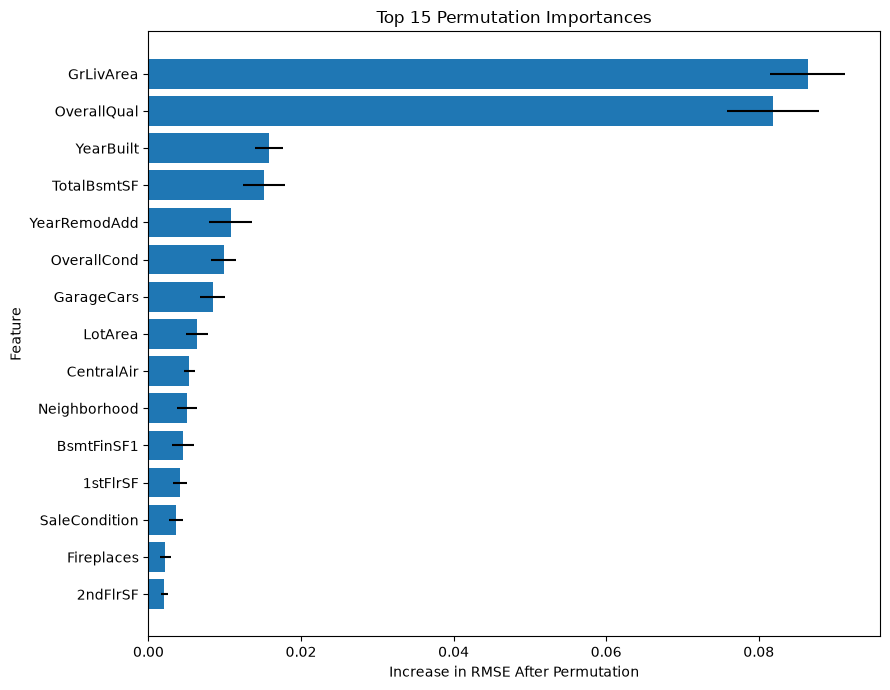

In [85]:
top_permutation_features = (
    permutation_importance_df
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .head(15)
    .sort_values("importance_mean")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_permutation_features["feature"],
    top_permutation_features["importance_mean"],
    xerr=top_permutation_features["importance_std"]
)

plt.xlabel("Increase in RMSE After Permutation")
plt.ylabel("Feature")
plt.title("Top 15 Permutation Importances")

plt.tight_layout()
plt.show()

## Final Model Summary

Several regression approaches were evaluated using the same training split and
5-fold cross-validation framework.

The evaluated model families included:

- Ridge regression
- Lasso regression
- ElasticNet
- Random Forest
- Gradient Boosting

Among the tested approaches, Gradient Boosting achieved the strongest
cross-validation performance.

The selected model uses:

- `learning_rate=0.1`
- `n_estimators=300`
- `max_depth=3`

The selected preprocessing pipeline includes:

- neighborhood-based `LotFrontage` imputation,
- median imputation for remaining numerical variables,
- explicit missing-value handling for categorical variables,
- one-hot encoding of categorical predictors,
- and no numerical scaling for the tree-based model.

The selected Gradient Boosting model achieved a mean 5-fold cross-validation
RMSE of approximately 0.1282 on the log-transformed target.

After model selection was completed, the pipeline was fitted on the full
training set and evaluated once on the previously untouched holdout set.

The final holdout RMSE was approximately 0.1410.

Holdout error analysis showed that prediction performance is strongest in the
middle of the price distribution. Lower-priced properties tend to be
overpredicted, while expensive properties tend to be underpredicted, indicating
some regression toward the center of the market.

Permutation importance identified `GrLivArea` and `OverallQual` as the two most
influential predictors for the final model, followed by variables such as
`YearBuilt`, `TotalBsmtSF`, `YearRemodAdd`, `OverallCond`, and `GarageCars`.

These feature-importance results describe the fitted model's predictive
behavior and should not be interpreted as causal effects.

The holdout set was used only for final evaluation and interpretation and was
not used for further model tuning.

In [86]:
print("Selected CV RMSE:")
print(
    gb_depth_results_df.loc[
        gb_depth_results_df["max_depth"] == 3,
        "mean_cv_rmse"
    ].iloc[0]
)

print("\nFinal Holdout RMSE:")
print(final_test_rmse)

Selected CV RMSE:
0.12818090509107966

Final Holdout RMSE:
0.14099309366610185
